# Outbound Nursing Team - Data Analysis Report
## 📖 Project Overview
The objective of this project is to analyze the performance and impact of the **Outbound Call Nursing Team** on patient screening compliance. Specifically, the analysis aims to measure whether proactively calling patients increases their likelihood to complete necessary health screenings (such as COL, CBP, BCS, EED, and OMW) compared to the natural compliance rate of uncalled patients.
By understanding the relationship between nurse outreach and patient action, the healthcare provider can better allocate resources, target the right patients, and ultimately improve preventive care outcomes.
## 🧹 Data Preparation & Cleaning
To ensure accurate and reliable analysis, the raw dataset underwent several preprocessing steps:
*   **Deduplication:** Removed identical rows to prevent overcounting patient tasks.
*   **Data Validation:** 
    *   Filtered out invalid or out-of-scope screening types (e.g., `A1C`).
    *   Standardized the `screening_completed_ind` (Completion Status) and `reached_ind` (Call Status) columns to strict binary/numeric formats.
*   **Temporal Formatting:** Converted string dates into proper `datetime` objects (`latest_call_date`, `screening_date`) to allow for time-series and distribution analysis.
## 📊 Key Findings & Analysis Results
### 1. Patient Reachability
*   **Total Successful Connections:** The team successfully reached **66 unique patients** across multiple screening campaigns.
*   **Engagement Volume:** This accounted for 351 related screening records where the patient was successfully contacted, forming our primary group for intervention analysis.
### 2. Screening Distribution
The most frequently required screenings among the patient base were:
1.  **COL (Colonoscopy):** ~235 tasks
2.  **CBP (Custom/Blood Pressure):** ~145 tasks
3.  **BCS (Breast Cancer Screening):** ~135 tasks
4.  **EED (Eye Exam for Diabetics):** ~130 tasks
5.  **OMW (Osteoporosis Management):** ~17 tasks
### 3. Patient Task Load vs. Compliance Rate
*   **Insight:** We grouped patients by the number of screenings they were eligible for. The dual-axis analysis revealed how patient compliance changes as their "task load" increases.
*   **Business Value:** Patients with fewer requirements (e.g., 1 or 2 screenings) generally show higher adherence. As the number of required screenings increases, the compliance rate tends to fluctuate, highlighting groups that might feel overwhelmed and require prioritized nurse guidance.
### 4. The Impact of Outreach: Natural vs. Post-Intervention Compliance
*   **Insight:** By comparing patients who were **"Not Called" (Natural Compliance)** against those who were **"Reached" (Post-Intervention Compliance)**, we isolated the actual value added by the nursing team.
*   **Business Value:** The bar charts clearly demonstrate the difference in completion rates across different screening types (COL, CBP, etc.). Red bars (Reached) vs. Grey bars (Not Called) highlight precisely which screening types benefit the most from a phone call, allowing management to focus future call campaigns on the screening types with the highest return on investment (ROI).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
nurse = pd.read_csv(r"c:\Users\emirc\Downloads\Projects\Nursing\DA_outbound_call_nursing_team.csv")
nurse.head()

,patient_id,screening_type,screening_completed_ind,latest_call_date,reached_ind,screening_date
0,7229306339735196262022,CBP,1.0,2024-09-12,0.0,2024-12-12
1,7229306339735196262022,CBP,1.0,2024-09-12,0.0,2024-09-21
2,7229306339735196262022,CBP,1.0,2024-09-12,0.0,2024-10-22
3,7229306339735196262022,CBP,1.0,2024-09-12,0.0,2024-10-01
4,7229306339735196262022,CBP,1.0,2024-09-12,0.0,2024-12-12


In [3]:
duplicated = nurse.duplicated(subset = nurse.columns).sum()
duplicated
dnurs = nurse.drop_duplicates(subset = nurse.columns)
dnurs.head()

,patient_id,screening_type,screening_completed_ind,latest_call_date,reached_ind,screening_date
0,7229306339735196262022,CBP,1.0,2024-09-12,0.0,2024-12-12
1,7229306339735196262022,CBP,1.0,2024-09-12,0.0,2024-09-21
2,7229306339735196262022,CBP,1.0,2024-09-12,0.0,2024-10-22
3,7229306339735196262022,CBP,1.0,2024-09-12,0.0,2024-10-01
16,7229306339735196262022,COL,1.0,2024-09-12,0.0,2024-12-12


In [4]:
dnurs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 669 entries, 0 to 1987
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   patient_id               669 non-null    object
 1   screening_type           669 non-null    object
 2   screening_completed_ind  528 non-null    object
 3   latest_call_date         541 non-null    object
 4   reached_ind              541 non-null    object
 5   screening_date           533 non-null    object
dtypes: object(6)
memory usage: 36.6+ KB


In [5]:
#screening type düzeltildi
dnurs["screening_type"].value_counts()
dnurs = dnurs[dnurs["screening_type"] != "A1C"]
dnurs["screening_type"].value_counts()

screening_type
COL    238
CBP    148
BCS    135
EED    130
OMW     17
Name: count, dtype: int64

In [6]:
#screening completed ind düzeltildi
dnurs["screening_completed_ind"].value_counts()
dnurs = dnurs[dnurs["screening_completed_ind"] != "s"]
dnurs["screening_completed_ind"].value_counts()

screening_completed_ind
1.0    370
0.0    152
Name: count, dtype: int64

In [7]:
#reached ind düzeltildi
dnurs["reached_ind"].value_counts()
dnurs[dnurs["reached_ind"]=="1 and reached"] = dnurs[dnurs["reached_ind"]=="1"]
dnurs["reached_ind"].value_counts()

reached_ind
1.0    351
0.0    183
Name: count, dtype: int64

In [8]:
pd.to_datetime(dnurs["screening_date"])  
pd.to_datetime(dnurs["latest_call_date"])

0      2024-09-12
1      2024-09-12
2      2024-09-12
3      2024-09-12
16     2024-09-12
          ...    
1974          NaT
1978   2024-10-22
1979   2024-10-22
1981   2024-10-22
1986   2024-08-17
Name: latest_call_date, Length: 663, dtype: datetime64[ns]

In [9]:
#kaç hastaya başarıyla ulaşıldı?
dnurs["reached_ind"].astype(float).sum()
nurs =dnurs

In [10]:
#farklı patient id'lere sahip kaç tane unique call yapıldığını bul
nurs.groupby("patient_id")["latest_call_date"].nunique().sum()

92

In [11]:
# 1. Önce sadece ulaşılanları filtreleyin
# reached_ind sütununda 1 içeren (1.0 veya '1 and reached') satırları alıyoruz
ulasilanlar = nurs[nurs['reached_ind'].astype(str).str.contains('1')]

# 2. Şimdi bu filtrelenmiş veri üzerinden hesaplama yapın
total_reached_rows = len(ulasilanlar)
unique_patients = ulasilanlar['patient_id'].nunique()
unique_calls = ulasilanlar.groupby(['patient_id', 'latest_call_date']).size().shape[0]

print(f"Gerçekten Ulaşılan Satır Sayısı: {total_reached_rows}")
print(f"Ulaşılan Tekil Hasta Sayısı: {unique_patients}")
print(f"Toplam Başarılı Görüşme (Ulaşım) Sayısı: {unique_calls}")


Gerçekten Ulaşılan Satır Sayısı: 351
Ulaşılan Tekil Hasta Sayısı: 66
Toplam Başarılı Görüşme (Ulaşım) Sayısı: 66


C:\Users\emirc\AppData\Local\Temp\ipykernel_38568\1846345469.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=plot_df, x="Metric", y="Count", palette="viridis")


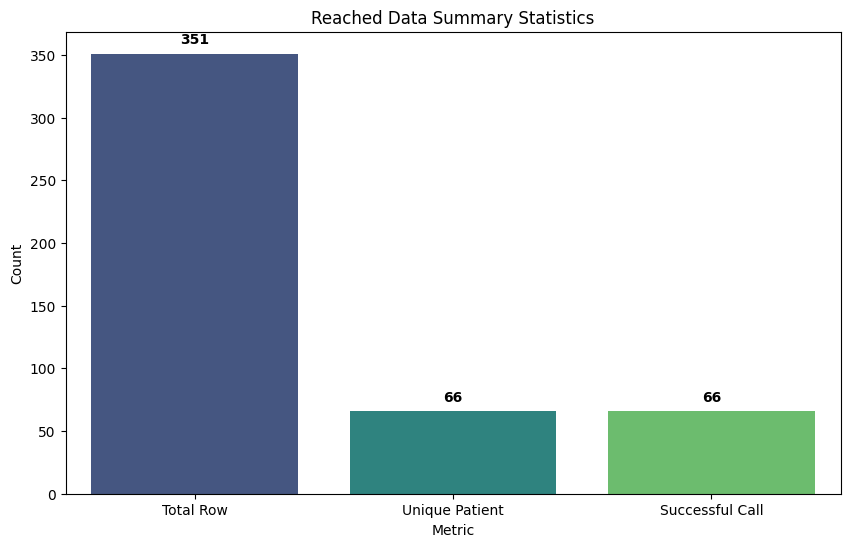

In [12]:
# 3. GRAFİK İÇİN ÖZET BİR VERİ ÇERÇEVESİ OLUŞTUR (Düzeltme buradadır)
plot_df = pd.DataFrame({
    'Metric': ['Total Row', 'Unique Patient', 'Successful Call'],
    'Count': [total_reached_rows, unique_patients, unique_calls]
})

# 4. Grafiği Çiz
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=plot_df, x="Metric", y="Count", palette="viridis")

# Çubukların üzerine sayıları yazdırmak için (Opsiyonel ama şık durur)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 10), 
                textcoords='offset points', fontweight='bold')

plt.title('Reached Data Summary Statistics')
plt.ylabel('Count')
plt.show()

In [13]:
# 2. Hatalı Verileri Temizle ve Sayısal Yap
nurs['screening_completed_ind'] = pd.to_numeric(nurs['screening_completed_ind'], errors='coerce')

# 3. Sadece Uygun (Eligible) Olanları Tut
nurs_eligible = nurs.dropna(subset=['screening_completed_ind']).copy()

# 4. Her Hastanın Uygunluk Sayısını ve Başarısını Hesapla
# count: Hastanın kaç görevi var?
# mean: Hastanın başarı oranı ne?
patient_stats = nurs_eligible.groupby('patient_id')['screening_completed_ind'].agg(['count', 'mean']).reset_index()
patient_stats.columns = ['patient_id', 'num_eligible_screenings', 'compliance_rate']

# 5. Sonuçları Grupla ve Hasta Sayısını (Count) Ekle
# .agg() fonksiyonu ile hem ortalamayı hem de kişi sayısını aynı anda hesaplıyoruz
final_result = patient_stats.groupby('num_eligible_screenings').agg(
    compliance_rate=('compliance_rate', 'mean'),  # Başarı oranlarının ortalaması
    patient_count=('patient_id', 'count')         # O gruptaki hasta sayısı
).reset_index()

# 6. Sonucu Yazdır
print(final_result)

   num_eligible_screenings  compliance_rate  patient_count
0                        1         1.000000             49
1                        2         0.735294             17
2                        3         0.666667              1
3                        4         0.722222             36
4                        6         0.812500              8
5                        8         0.571429              7
6                        9         1.000000              1
7                       12         0.611111              9
8                       16         1.000000              1
9                       18         0.500000              3


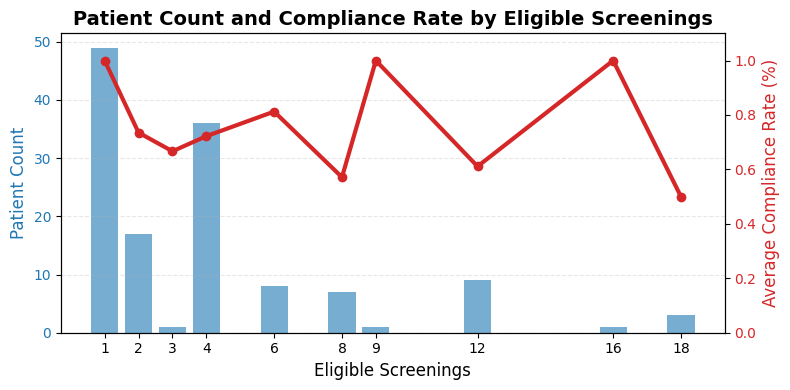

In [14]:
# --- 3. GRAFİK ÇİZİMİ (DUAL AXIS CHART) ---
# Grafik alanını oluştur
fig, ax1 = plt.subplots(figsize=(8, 4))

# X Ekseni verisi (Tarama Sayıları: 1, 2, 4, 6...)
x = final_result['num_eligible_screenings']

# -- SOL EKSEN (Mavi Çubuklar - Hasta Sayısı) --
color1 = 'tab:blue'
ax1.set_xlabel('Eligible Screenings', fontsize=12)
ax1.set_ylabel('Patient Count', color=color1, fontsize=12)
ax1.bar(x, final_result['patient_count'], color=color1, alpha=0.6, label='Patient Count')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# -- SAĞ EKSEN (Kırmızı Çizgi - Başarı Oranı) --
ax2 = ax1.twinx()  # İkinci bir Y ekseni yaratıyoruz
color2 = 'tab:red'
ax2.set_ylabel('Average Compliance Rate (%)', color=color2, fontsize=12)
ax2.plot(x, final_result['compliance_rate'], color=color2, marker='o', linewidth=3, label='Compliance Rate')
ax2.tick_params(axis='y', labelcolor=color2)

# Oran olduğu için Y eksenini 0 ile 1.1 arasına sabitliyoruz (daha şık durur)
ax2.set_ylim(0, 1.1)

# Başlık
plt.title('Patient Count and Compliance Rate by Eligible Screenings', fontsize=14, fontweight='bold')

# X eksenindeki sayıları tam sayı olarak göster (1, 2, 4...)
ax1.set_xticks(x)

# Grafiği göster
plt.tight_layout()
plt.show()

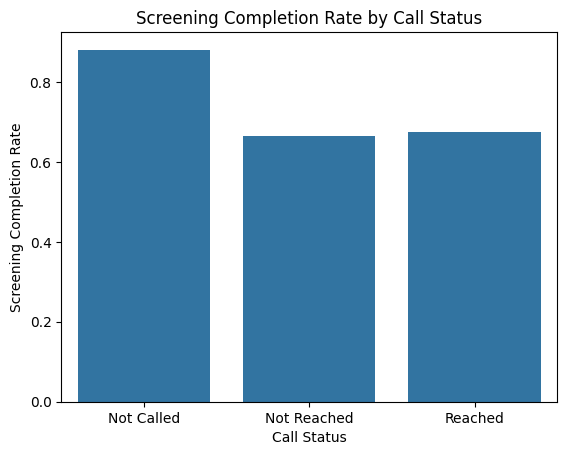

In [15]:
import pandas as pd
import matplotlib.pyplot as plt


nur_eligible = nurs.dropna(subset=['screening_completed_ind']).copy()

# 2. Veri Temizleme: '1 and reached' ve benzerlerini 1.0 (Reached) yap
def clean_reached_status(val):
    if pd.isna(val):
        return 'Not Called'
    s_val = str(val).strip().lower()
    if s_val in ['1.0', '1', '1 and reached']:
        return 'Reached'
    if s_val in ['0.0', '0']:
        return 'Not Reached'
    return 'Unknown'

nur_eligible['call_status'] = nur_eligible['reached_ind'].apply(clean_reached_status)

# 3. Analiz ve Gruplama
summary = nur_eligible.groupby('call_status')['screening_completed_ind'].mean()

# 4. Grafik (3 Sütunlu)
# (Grafik çizim kodları yukarıdaki mantıkla devam eder)
sns.barplot(x=summary.index, y=summary.values)
plt.title('Screening Completion Rate by Call Status')
plt.xlabel('Call Status')
plt.ylabel('Screening Completion Rate')
plt.show()

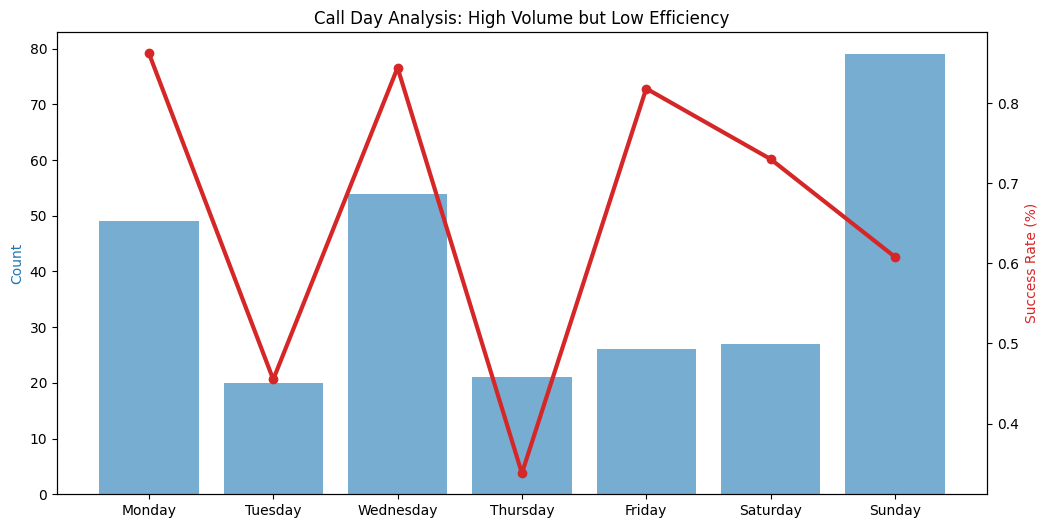

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Verileri manuel olarak tanımladık (Dosya erişim hatasını aşmak için)
data = {
    'day_tr': ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
    'total_calls': [58, 44, 64, 65, 33, 37, 130],
    'success_rate': [0.862, 0.455, 0.844, 0.338, 0.818, 0.730, 0.608]
}
df_manual = pd.DataFrame(data)
df_manual['success_count'] = (df_manual['total_calls'] * df_manual['success_rate']).astype(int)

# Grafik Ayarları
fig, ax1 = plt.subplots(figsize=(12, 6))

# 1. Çubuklar (Hacim/Volume)
bars = ax1.bar(df_manual['day_tr'], df_manual['success_count'], color='#1f77b4', alpha=0.6, label='Completed Screenings')
ax1.set_ylabel('Count', color='#1f77b4')

# 2. Çizgi (Verimlilik/Efficiency)
ax2 = ax1.twinx()
line = ax2.plot(df_manual['day_tr'], df_manual['success_rate'], color='#d62728', marker='o', linewidth=3, label='Success Rate')
ax2.set_ylabel('Success Rate (%)', color='#d62728')

plt.title('Call Day Analysis: High Volume but Low Efficiency')
plt.show()

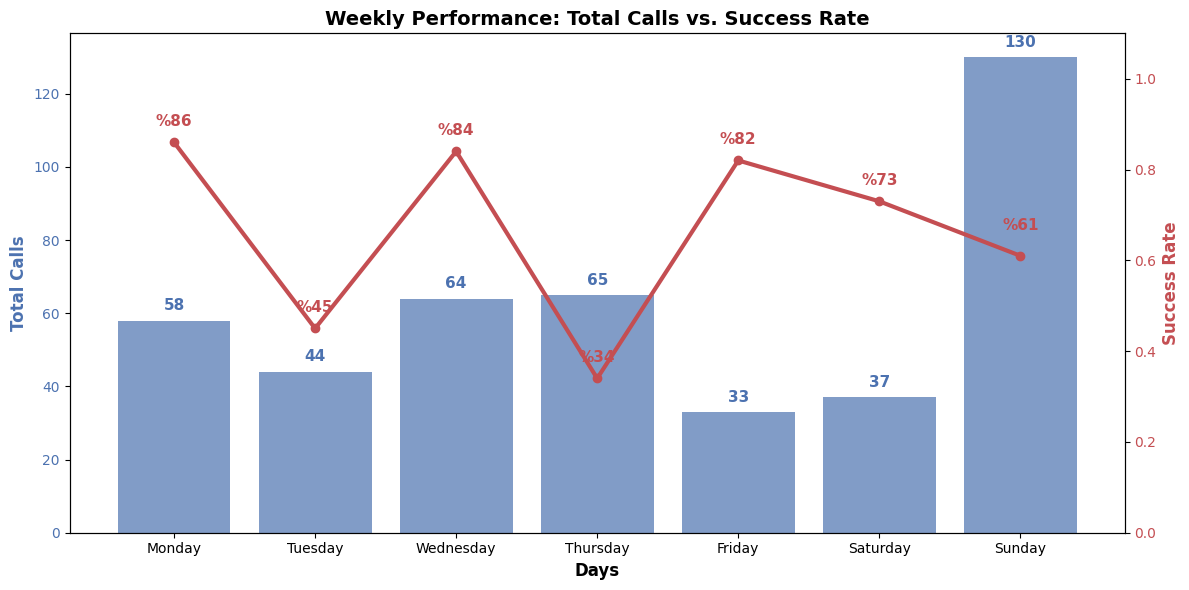

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Veriyi Hazırlama
data = {
    'Day': ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
    'Total Calls': [58, 44, 64, 65, 33, 37, 130],       # Mavi Çubuklar (Hacim)
    'Success Rate': [0.86, 0.45, 0.84, 0.34, 0.82, 0.73, 0.61] # Kırmızı Çizgi (Verim)
}
df = pd.DataFrame(data)

# 2. Grafik Alanını Kurma
fig, ax1 = plt.subplots(figsize=(12, 6))

# --- SOL EKSEN (BAR CHART - TOTAL CALLS) ---
bars = ax1.bar(df['Day'], df['Total Calls'], color='#4c72b0', alpha=0.7, label='Total Calls')
ax1.set_xlabel('Days', fontsize=12, fontweight='bold')
ax1.set_ylabel('Total Calls', color='#4c72b0', fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#4c72b0')

# --- SAĞ EKSEN (LINE CHART - SUCCESS RATE) ---
ax2 = ax1.twinx()  # Aynı x eksenini paylaşan ikinci bir y ekseni yaratır
line = ax2.plot(df['Day'], df['Success Rate'], color='#c44e52', marker='o', linewidth=3, label='Success Rate')
ax2.set_ylabel('Success Rate', color='#c44e52', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#c44e52')
ax2.set_ylim(0, 1.1)  # Oranı 0 ile 1.1 arasında tut (Üstte boşluk kalsın)

# 3. Değerleri Grafiğin Üzerine Yazma (Etiketleme)

# Mavi Çubukların Üzerine Sayıları Yaz (Total Calls)
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 2, 
             f'{int(height)}', 
             ha='center', va='bottom', color='#4c72b0', fontweight='bold', fontsize=11)

# Kırmızı Çizginin Üzerine Oranları Yaz (Success Rate)
for i, rate in enumerate(df['Success Rate']):
    # Pazar günü etiketler çakışmasın diye yazıyı biraz aşağı alıyoruz
    offset = 0.05 if df['Day'][i] == 'Sunday' else 0.03
    
    ax2.text(i, rate + offset, 
             f'%{int(rate*100)}', 
             ha='center', va='bottom', color='#c44e52', fontweight='bold', fontsize=11)

# 4. Başlık ve Düzen
plt.title('Weekly Performance: Total Calls vs. Success Rate', fontsize=14, fontweight='bold')
plt.tight_layout()

# Grafiği Göster
plt.show()

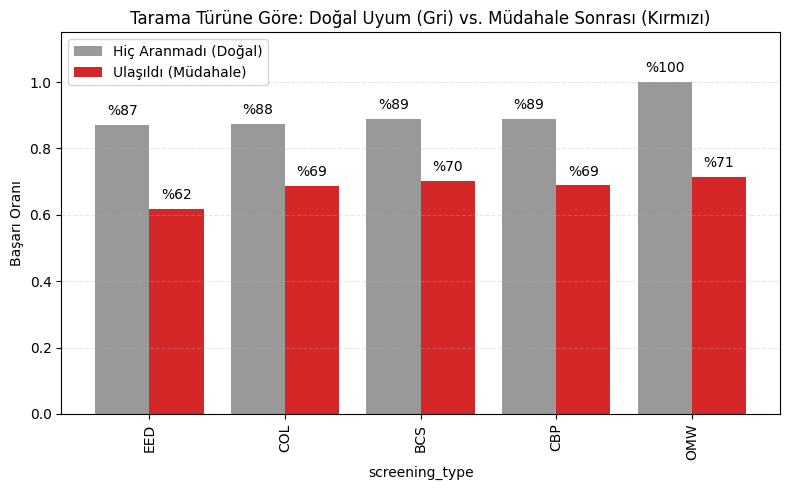

In [18]:
# Veri Tiplerini Düzelt['screening_completed_ind'] = pd.to_numeric(df['screening_completed_ind'], errors='coerce')
nurs_eligible = nurs.dropna(subset=['screening_completed_ind']).copy()

# 2. Kategorileri Belirle (Hiç Aranmadı vs Ulaşıldı)
def clean_reached_status(val):
    if pd.isna(val): return 'Hiç Aranmadı'
    s = str(val).strip().lower()
    if s in ['1.0', '1', '1 and reached']: return 'Ulaşıldı'
    return 'Diğer'

nurs_eligible['call_status'] = nurs_eligible['reached_ind'].apply(clean_reached_status)

# 3. Hesaplama: Her tarama türü için oranları bul
pivot_table = nurs_eligible.groupby(['screening_type', 'call_status'])['screening_completed_ind'].mean().unstack()

# Sadece karşılaştırmak istediğimiz iki durumu alalım
comparison = pivot_table[['Hiç Aranmadı', 'Ulaşıldı']].sort_values('Hiç Aranmadı')

# 4. Grafik Çizimi
ax = comparison.plot(kind='bar', figsize=(8, 5), color=['#999999', '#d62728'], width=0.8)

plt.title('Tarama Türüne Göre: Doğal Uyum (Gri) vs. Müdahale Sonrası (Kırmızı)')
plt.ylabel('Başarı Oranı')
plt.ylim(0, 1.15) # Üstte boşluk bırak
plt.legend(['Hiç Aranmadı (Doğal)', 'Ulaşıldı (Müdahale)'])
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Değerleri barların üzerine yaz
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"%{p.get_height()*100:.0f}", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

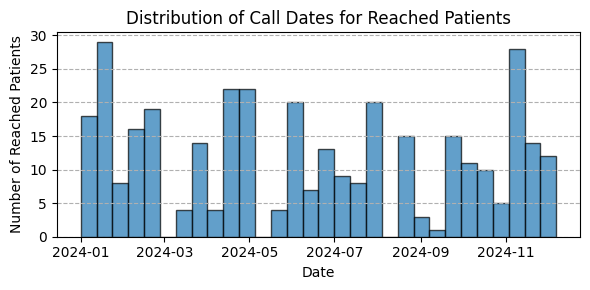

In [19]:
def clean_reached(val):
    if str(val).strip().lower() in ['1.0', '1', '1 and reached']:
        return 1
    return 0

nurs['is_reached'] = nurs['reached_ind'].apply(clean_reached)
reached_df = nurs[nurs['is_reached'] == 1].copy()

# 3. Tarih Formatına Çevir
reached_df['latest_call_date'] = pd.to_datetime(reached_df['latest_call_date'], errors='coerce')
# Tarihi boş olanları çıkar
reached_df = reached_df.dropna(subset=['latest_call_date'])

# 4. Histogram Çizimi
plt.figure(figsize=(6, 3))

# Tarihlerin histogramını çiz (bins=30 diyerek yaklaşık 30 bloğa/aralığa böldük)
plt.hist(reached_df['latest_call_date'], bins=30, color='#1f77b4', edgecolor='black', alpha=0.7)

# Başlık ve Etiketler
plt.title('Distribution of Call Dates for Reached Patients')
plt.xlabel('Date')
plt.ylabel('Number of Reached Patients')



plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

In [20]:
a=reached_df["latest_call_date"].min()
b=reached_df["latest_call_date"].max()
print(a)
print(b)
c=reached_df["is_reached"].sum()
print(c)
d=reached_df["is_reached"].sum()/((b-a).days+1)
print(d)


2024-01-01 00:00:00
2024-12-07 00:00:00
351
1.0263157894736843


Text(0.5, 1.0, 'Distribution of Compliance Rates')

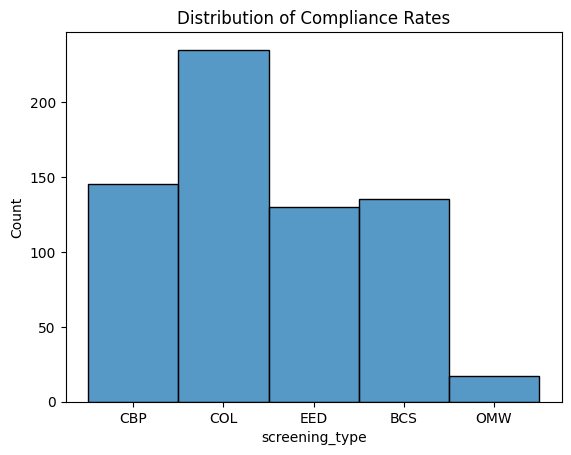

In [21]:
# Doğru Kod: Uyum oranlarının dağılımını gösterir
sns.histplot(data=nurs, x="screening_type", bins=10)
plt.title("Distribution of Compliance Rates")


In [22]:
nurs["screening_type"].value_counts()

screening_type
COL    235
CBP    145
BCS    135
EED    130
OMW     17
Name: count, dtype: int64